# Задание 1. Архитектура U-Net

В этом задании вам необходимо создать U-Net-подобную сеть для сегментации документов.

В качестве датасета для обучения нейросети будет использоваться фрагмент [midv500 🎓[arxiv]](https://arxiv.org/abs/1807.05786). Это датасет, содержащий фотографии документов, таких как паспорт или водительское удостоверение.

## Формат результата

Корректно прописанная U-Net-подобная сеть со skip connections. Параметры слоев согласованы. Вывод `torchsummary` без ошибок:

```
  ----------------------------------------------------------------
          Layer (type)               Output Shape         Param #
  ================================================================

  ....

  ================================================================
  Total params:
  
  ...

```


## Загрузка данныx







Импорт необходимых библиотек:

In [1]:
!pip install -q lightning==2.5.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.3/815.3 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 65.7 MB/s eta 0:00:00


In [2]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from PIL import Image
from torchsummary import summary
from torchvision import tv_tensors
from torchvision.io import read_image
from torchvision.transforms import v2
from torchvision.utils import make_grid
from torch.utils.data import Dataset, DataLoader

In [3]:
! wget -qN https://edunet.kea.su/repo/EduNet-web_dependencies/datasets/midv500p.zip
! unzip -q midv500p.zip
! rm midv500p.zip

Класс `MaskDataset` возвращает часть датасета для обучения при `train_part=True` и тестовую часть при `train_part=False`.

Каждый экземпляр датасета состоит из двух изображений: входного изображения и размеченной маски.

In [4]:
from PIL import Image, ImageFile

# To bypass error on corrupted files:
# https://stackoverflow.com/questions/12984426/pil-ioerror-image-file-truncated-with-big-images
# ImageFile.LOAD_TRUNCATED_IMAGES = False


class MaskDataset(Dataset):
    def __init__(
        self,
        train_part=True,
        transforms=None,  # for image and mask
        transform=None,  # for image only
        target_transform=None,  # for mask only
        path="midv500p",
    ):
        self.transform = transform
        self.transforms = transforms
        self.target_transform = target_transform
        path += "/train" if train_part else "/val"
        files = glob.glob(path + "/image/*")
        self.loaded_images = []
        self.loaded_masks = []

        for filename in files:  # cache all data in memory
            self.loaded_images.append(read_image(filename) / 255)
            mask_fn = filename.replace("image", "mask").replace("jpg", "png")
            self.loaded_masks.append(read_image(mask_fn) / 255)

    def __getitem__(self, i):
        img = self.loaded_images[i]
        mask = self.loaded_masks[i]
        if self.transforms is not None:
            img, mask = self.transforms(
                tv_tensors.Image(img),
                tv_tensors.Mask(mask),
            )
        if self.transform is not None:
            img = self.transform(img)

        if self.target_transform is not None:
            mask = self.target_transform(mask)
        return img, mask

    def __len__(self):
        return len(self.loaded_images)

Подумайте, какие аугментации и нормализации приемлемы, и примените их. Обратите внимание, что по коду выше `transforms` применяется и к маске, и к изображению, `transform` — только к изображению, а `target_transform` — только к маске.

Допускается использовать библиотеку [albumentations 🐾[git]](https://github.com/albumentations-team/albumentations).

In [5]:
from torchvision.transforms import v2


v2_transforms = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Resize((224, 224), antialias=True),  # antialias to suppress warning
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomRotation(degrees=45),
        # Your code here
    ]
)

trainset = MaskDataset(train_part=True, transforms=v2_transforms)
valset = MaskDataset(train_part=False, transforms=v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((224, 224), antialias=True),
]))

train_loader = DataLoader(trainset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(valset, batch_size=4, shuffle=False, num_workers=2)

Убедитесь, что код работает. Для этого воспользуйтесь приведенным ниже тестом.

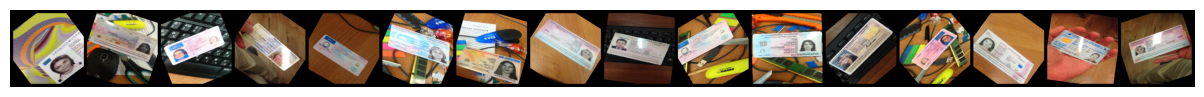

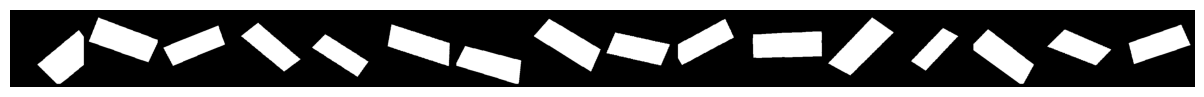

In [6]:
def show(batch, cols=16):
    cols = min(cols, len(batch))
    img_grid = make_grid(batch[:cols], padding=10, nrow=cols)
    plt.figure(figsize=(cols, 1))
    plt.axis("off")
    plt.imshow(np.transpose((img_grid * 255).numpy().astype(np.uint8), (1, 2, 0)))


images, masks = next(iter(train_loader))

show(images)
show(masks)

## Модель

Опишите структуру  модели. Необходимо реализовать [UNet-подобную 🎓[arxiv]](https://arxiv.org/pdf/1505.04597.pdf) архитектуру. На выходе модели — logit-ы.

Совет: в этом задании не будет строгих требований на точность. Используйте небольшое количество каналов и ограничьтесь двумя-тремя сжимающими и таким же количеством разжимающих слоев.


In [7]:
class MiniUnet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.pool3 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )

        # Decoder
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
        )

        self.out_conv = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        # Bottleneck
        b = self.bottleneck(self.pool3(e3))
        # Decoder с skip connections
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        out = self.out_conv(d1)
        return out

Проверим модель:

In [8]:
from torchsummary import summary

model = MiniUnet()
summary(model, (3, 224, 224), device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 224, 224]             448
       BatchNorm2d-2         [-1, 16, 224, 224]              32
              ReLU-3         [-1, 16, 224, 224]               0
            Conv2d-4         [-1, 16, 224, 224]           2,320
       BatchNorm2d-5         [-1, 16, 224, 224]              32
              ReLU-6         [-1, 16, 224, 224]               0
         MaxPool2d-7         [-1, 16, 112, 112]               0
            Conv2d-8         [-1, 32, 112, 112]           4,640
       BatchNorm2d-9         [-1, 32, 112, 112]              64
             ReLU-10         [-1, 32, 112, 112]               0
           Conv2d-11         [-1, 32, 112, 112]           9,248
      BatchNorm2d-12         [-1, 32, 112, 112]              64
             ReLU-13         [-1, 32, 112, 112]               0
        MaxPool2d-14           [-1, 32,

# Задание 2. Обучение модели

Обучите модель из предыдущего задания, используя Lightning:

- В качестве loss можно использовать BCE (`BCELoss` [🛠️[doc]](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html), `BCEWithLogitsLoss` [🛠️[doc]](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html)), IoU, Dice или их комбинацию.
- Убедитесь, что модель обучается.
- Вычислите метрику качества на валидационной выборке (например, [IoU 📚[wiki]](https://en.wikipedia.org/wiki/Jaccard_index)).

## Формат результата

1.  График целевой метрики для вашей модели. Предпочтительно в формате TB или WandB.
2.  Сегментированные изображения документов.

Пример изображения:

<img src ="https://edunet.kea.su/repo/EduNet-web_dependencies/dev-2.4/Exercises/EX11/result_2_task_ex11.png">

## Метрика IoU

Для вычисления IoU метрики будем использовать библиотеку SMP.

Установка и импорт необходимых библиотек:

In [9]:
!pip install -q lightning==2.5.0 segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.7 MB/s eta 0:00:00


In [10]:
import torch
import torchvision
import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from segmentation_models_pytorch.losses import JaccardLoss
from segmentation_models_pytorch.metrics import get_stats, iou_score
from segmentation_models_pytorch.losses.constants import BINARY_MODE

Мы привыкли работать с TorchMetrics. Для удобной работы с метриками из библиотеки SMP напишем класс-адаптер.
Важно: обратите внимание, что `update` принимает в качестве `pred` logit-ы.

In [11]:
class SMPMetricAdapter:
    values = None

    def __init__(self, metric):
        self.reset()
        self.metric = metric

    def compute(self):
        return torch.Tensor(self.values).mean()

    def update(self, pred, gt):
        pred = pred.cpu().sigmoid()
        gt = gt.cpu().long()
        tp, fp, fn, tn = get_stats(pred, gt, mode="binary", threshold=0.5)
        metric_val = self.metric(tp, fp, fn, tn, reduction="micro")
        self.values.append(metric_val)

    def reset(self):
        self.values = []

Теперь свою метрику можно создать так:

In [12]:
from segmentation_models_pytorch.metrics import iou_score

iou_from_smp = SMPMetricAdapter(iou_score)

## Обучение

В этом блоке разместите код пайплайна обучения на Lightning:

In [13]:
import lightning as L
from segmentation_models_pytorch.metrics import iou_score


class Pipeline(L.LightningModule):
    def __init__(self, model, lr=0.001):
        super().__init__()
        self.model = model
        self.lr = lr
        self.loss_fn = nn.BCEWithLogitsLoss()
        self.train_iou = SMPMetricAdapter(iou_score)
        self.val_iou = SMPMetricAdapter(iou_score)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y.float())
        self.train_iou.update(logits.detach(), y)
        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_train_epoch_end(self):
        self.log("train_iou", self.train_iou.compute(), prog_bar=True)
        self.train_iou.reset()

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y.float())
        self.val_iou.update(logits.detach(), y)
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_validation_epoch_end(self):
        self.log("val_iou", self.val_iou.compute(), prog_bar=True)
        self.val_iou.reset()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
        return [optimizer], [scheduler]

Если для визуализации результатов обучения вы используете TensorBoard, инициализируйте его в ячейке ниже:

In [14]:
%load_ext tensorboard
%tensorboard --logdir lightning_logs

Launching TensorBoard...

KeyboardInterrupt: 

Настройте `Trainer` и обучите модель. Воспользуйтесь `ModelCheckpoint` для сохранения состояния модели, соответствующего лучшему IoU на валидационных данных:

In [15]:
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger

mini_unet = MiniUnet()
pipeline = Pipeline(mini_unet, lr=0.001)

checkpoint_callback = ModelCheckpoint(
    monitor="val_iou",
    mode="max",
    save_top_k=1,
    filename="my_unet",
    verbose=True,
)

logger = TensorBoardLogger("lightning_logs", name="my_unet")

trainer = Trainer(
    max_epochs=10,
    callbacks=[checkpoint_callback],
    logger=logger,
    log_every_n_steps=1,
)

trainer.fit(pipeline, train_loader, val_loader)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | model   | MiniUnet          | 483 K  | train
1 | loss_fn | BCEWithLogitsLoss | 0      | train
------------------------------------------------------
483 K     Trainable params
0         Non-trainable params
483 K     Total params
1.934     Total estimated model params size (MB)
58        Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

INFO: Epoch 7, global step 144: 'val_iou' reached 0.75444 (best 0.75444), saving model to 'lightning_logs/my_unet/version_0/checkpoints/my_unet.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 7, global step 144: 'val_iou' reached 0.75444 (best 0.75444), saving model to 'lightning_logs/my_unet/version_0/checkpoints/my_unet.ckpt' as top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 8, global step 162: 'val_iou' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 8, global step 162: 'val_iou' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 9, global step 180: 'val_iou' reached 0.78351 (best 0.78351), saving model to 'lightning_logs/my_unet/version_0/checkpoints/my_unet.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 9, global step 180: 'val_iou' reached 0.78351 (best 0.78351), saving model to 'lightning_logs/my_unet/version_0/checkpoints/my_unet.ckpt' as top 1
INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


## Валидация

Загрузите веса модели с лучшим IoU из контрольной точки.

Совет: в случае возникновения проблем с загрузкой модели вам поможет [блокнот про Lightning 🥨[colab]](https://colab.research.google.com/drive/16Q_k7NR4oGMh5CrqErsdzWwpihlK4lbH), раздел CheckPoint.

In [16]:
ckpt_path = checkpoint_callback.best_model_path
print(f"Best checkpoint: {ckpt_path}")

checkpoint = torch.load(ckpt_path, weights_only=True, map_location="cpu")
model_state = {
    k.replace("model.", "", 1): v
    for k, v in checkpoint["state_dict"].items()
    if k.startswith("model.")
}
mini_unet.load_state_dict(model_state)
mini_unet.eval()
print("Веса успешно загружены")

Best checkpoint: lightning_logs/my_unet/version_0/checkpoints/my_unet.ckpt
Веса успешно загружены


Оцените результат визуально:

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def show_valset_pred(model, cols=16):
    model.to(device)
    images, pred_masks = [], []
    try:
        tmp = valset.transform
        valset.transform = None
        for batch in valset:
            with torch.no_grad():
                img, mask = batch
                images.append(img.unsqueeze(0))
                output = model(img.unsqueeze(0).to(device))
                pred_masks.append(output.cpu())

    finally:
        valset.transform = tmp
    show(torch.stack(images).squeeze()[:cols, ...])
    binary_mask = torch.stack(pred_masks) > 0.5
    show(binary_mask.squeeze(1).float()[:cols, ...])

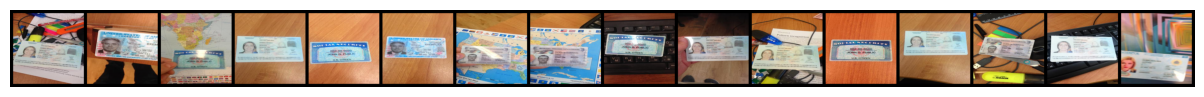

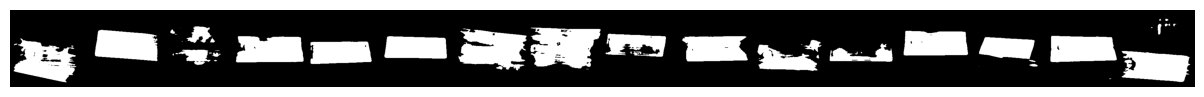

In [18]:
show_valset_pred(mini_unet, 16)

# Задание 3. Сравнение моделей

- Импортируйте UNet из [SMP 🐾[git]](https://github.com/qubvel/segmentation_models.pytorch#models), в качестве backbone используйте EfficientNet-b0 (не предобученный).
- Обучите ее на том же датасете и с теми же гиперпараметрами, которые вы использовали во 2-м задании.
- Сравните целевую метрику для обеих моделей.
- Визуализируйте результаты сегментации.

## Формат результата

1.  Графики целевой метрики для разных моделей. Предпочтительно в формате TB или WandB.
2.  Сегментированные изображения документов.

Пример изображения:

<img src ="https://edunet.kea.su/repo/EduNet-web_dependencies/dev-2.4/Exercises/EX11/result_3_task_ex11.png">

## Обучение

Загрузите непредобученную модель:

In [19]:
import segmentation_models_pytorch as smp
from IPython.display import clear_output

smp_unet = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None,
)

clear_output()

При необходимости добавьте дополнительную предобработку данных.

Обучите модель:

In [24]:
smp_pipeline = Pipeline(smp_unet, lr=1e-4)

smp_checkpoint_callback = ModelCheckpoint(
    monitor="val_iou",
    mode="max",
    save_top_k=1,
    filename="smp_unet",
    verbose=True,
)

smp_logger = TensorBoardLogger("lightning_logs", name="smp_unet")

smp_trainer = Trainer(
    max_epochs=10,
    callbacks=[smp_checkpoint_callback],
    logger=smp_logger,
    log_every_n_steps=1,
)

smp_trainer.fit(smp_pipeline, train_loader, val_loader)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | model   | Unet              | 6.3 M  | eval 
1 | loss_fn | BCEWithLogitsLoss | 0      | train
------------------------------------------------------
6.3 M     Trainable params
0         Non-trainable params
6.3 M     Total params
25.006    Total estimated model params size (MB)
1         Modules in train mode
324       Modules in eval mode
INFO:lightning.pytorch.callbacks.

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 0, global step 18: 'val_iou' reached 0.10958 (best 0.10958), saving model to 'lightning_logs/smp_unet/version_1/checkpoints/smp_unet.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 18: 'val_iou' reached 0.10958 (best 0.10958), saving model to 'lightning_logs/smp_unet/version_1/checkpoints/smp_unet.ckpt' as top 1


...

INFO: Epoch 7, global step 144: 'val_iou' reached 0.70075 (best 0.70075), saving model to 'lightning_logs/smp_unet/version_1/checkpoints/smp_unet.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 7, global step 144: 'val_iou' reached 0.70075 (best 0.70075), saving model to 'lightning_logs/smp_unet/version_1/checkpoints/smp_unet.ckpt' as top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 8, global step 162: 'val_iou' reached 0.70480 (best 0.70480), saving model to 'lightning_logs/smp_unet/version_1/checkpoints/smp_unet.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 8, global step 162: 'val_iou' reached 0.70480 (best 0.70480), saving model to 'lightning_logs/smp_unet/version_1/checkpoints/smp_unet.ckpt' as top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 9, global step 180: 'val_iou' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 9, global step 180: 'val_iou' was not in top 1
INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


## Валидация

Загрузите веса модели с лучшим IoU из контрольной точки:

In [28]:
ckpt_path = smp_checkpoint_callback.best_model_path
print(f"Best SMP checkpoint: {ckpt_path}")

checkpoint = torch.load(ckpt_path, weights_only=True, map_location="cpu")

smp_model_state = {
    k.replace("model.", "", 1): v
    for k, v in checkpoint["state_dict"].items()
    if k.startswith("model.")
}
print(f"Загружено ключей: {len(smp_model_state)}")

missing, unexpected = smp_unet.load_state_dict(smp_model_state, strict=False)
smp_unet.eval()


Best SMP checkpoint: lightning_logs/smp_unet/version_1/checkpoints/smp_unet.ckpt
Загружено ключей: 420


Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identit

Визуализируем результат для модели из 1-го задания:

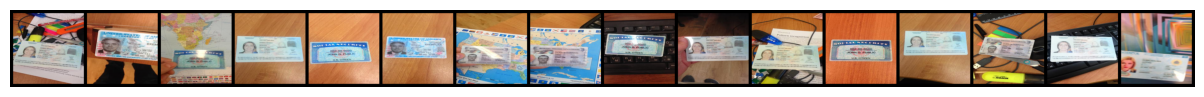

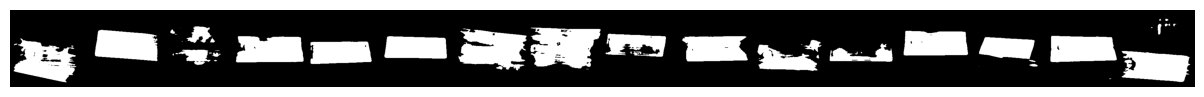

In [29]:

show_valset_pred(mini_unet, 16)


И для модели из SMP:

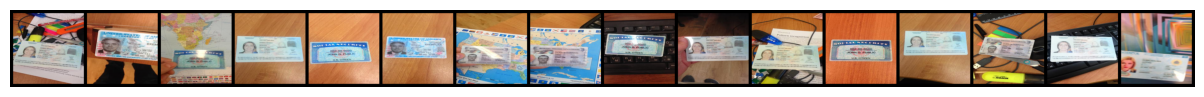

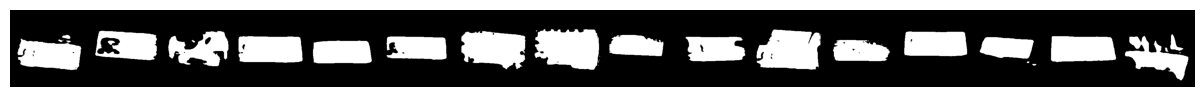

In [30]:
show_valset_pred(smp_unet, 16)